I hereby using the US_ACCIDENT_MARCH dataset for project to get some useful insights, trends and build a suitable model for it 

In [1]:
#! pip install feature_engine

In [2]:
#!pip install xgboost

In [3]:
# importing library 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer 
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

In [4]:
pd.set_option('display.max_colwidth', None)

In [5]:
df= pd.read_csv('US_Accidents_March23.csv')

In [6]:
df.sample(5)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
1333018,A-1342806,Source2,2,2020-10-16 07:48:56,2020-10-16 09:58:17,43.017071,-83.696037,NaN,NaN,0.000,...,False,False,False,False,False,False,Night,Day,Day,Day
5044010,A-5082248,Source1,2,2022-09-13 07:56:30.000000000,2022-09-13 08:47:00.000000000,38.452584,-121.361394,38.452631,-121.347518,0.751,...,False,False,False,False,False,False,Day,Day,Day,Day
6549332,A-6597665,Source1,2,2020-12-14 21:02:00,2020-12-14 22:17:08,29.091333,-82.244668,29.090140,-82.241783,0.193,...,False,False,False,False,True,False,Night,Night,Night,Night
2714838,A-2724712,Source2,2,2018-07-25 11:11:30,2018-07-25 11:56:18,33.946175,-118.020271,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
6787902,A-6837014,Source1,2,2020-10-29 12:43:00,2020-10-29 22:47:30,38.903647,-76.850650,38.827638,-76.878033,5.454,...,False,False,False,False,False,False,Day,Day,Day,Day


In [7]:
df.shape 

(7728394, 46)

we have around 7.7 million(77 lakh) rows and 46 columns

In [8]:
# here i combine both the dtype and missing values to easily understand the dataframe
info = pd.DataFrame({
    "dtype":df.dtypes,
    "missing_values":df.isna().sum()
    })                     
info

,dtype,missing_values
ID,object,0
Source,object,0
Severity,int64,0
Start_Time,object,0
End_Time,object,0
Start_Lat,float64,0
Start_Lng,float64,0
End_Lat,float64,3402762
End_Lng,float64,3402762
Distance(mi),float64,0


Severity is simply defined as the degree of hardness of a specific thing

In [9]:
sample_des = df['Description'][np.random.randint(0,df.shape[0],5)]
sample_des

7139196                                                     At PA-63/Welsh Rd - Accident.
7680191    Between 59th Ave/Exit 138 and 67th Ave/Exit 137 - Accident. Left lane blocked.
6224891                     Incident on CATTLEMEN RD near HOUSE 61850 Drive with caution.
6947748                                              At Mack Rd/Bruceville Rd - Accident.
3782297                                Incident on I-24 WB near MM 62 Drive with caution.
Name: Description, dtype: object

The Description though contain some information about the accident (most probably about the incident location) but what i assume it will probaably not help in my analysis atleast for now.

In [10]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


county states the accident tooks place in which administrative division -> clusters 


In [11]:
counties = df['County'].value_counts()   # this will give us the information about the consistuency where major accidents took
counties.sort_values(ascending=False)

County
Los Angeles    526851
Miami-Dade     251601
Orange         241275
Harris         181196
Dallas         157024
                ...  
Mcminn              1
Glascock            1
Woods               1
Mellette            1
Ness                1
Name: count, Length: 1871, dtype: int64

In [12]:
df[['Start_Time','End_Time']].sample(5)   # Evaluate the journey time and ramove these start time and end time column

,Start_Time,End_Time
1283311,2020-09-10 13:36:21,2020-09-10 15:10:43
2231603,2019-03-27 08:26:32,2019-03-27 09:12:00
4969489,2022-01-05 07:31:23.000000000,2022-01-05 08:49:38.000000000
461756,2017-06-18 15:05:24,2017-06-18 15:35:04
2885780,2018-04-19 07:31:58,2018-04-19 08:31:41


In [13]:
df['Distance(mi)'].describe()

count    7.728394e+06
mean     5.618423e-01
std      1.776811e+00
min      0.000000e+00
25%      0.000000e+00
50%      3.000000e-02
75%      4.640000e-01
max      4.417500e+02
Name: Distance(mi), dtype: float64

In [14]:
df['Source'].value_counts()

Source
Source1    4325632
Source2    3305373
Source3      97389
Name: count, dtype: int64

In [15]:
df.loc[df['Severity']==3 ,['Distance(mi)']].sample(10)

,Distance(mi)
335409,0.010
2293763,0.000
2809255,0.180
257047,0.000
3343688,1.880
2926771,0.000
7298617,0.526
2173088,0.000
943344,1.790
2488745,0.000


In [16]:
df.select_dtypes(include='number').corr()['Severity']  #  this method is used to find the correlation of various numerical column with Severity

Severity             1.000000
Start_Lat            0.069060
Start_Lng            0.052862
End_Lat              0.083724
End_Lng              0.093190
Distance(mi)         0.034787
Temperature(F)      -0.020327
Wind_Chill(F)       -0.070039
Humidity(%)          0.022293
Pressure(in)         0.042347
Visibility(mi)      -0.003473
Wind_Speed(mph)      0.040214
Precipitation(in)    0.021080
Name: Severity, dtype: float64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
severities = df['Severity'].value_counts()
severities

Severity
2    6156981
3    1299337
4     204710
1      67366
Name: count, dtype: int64

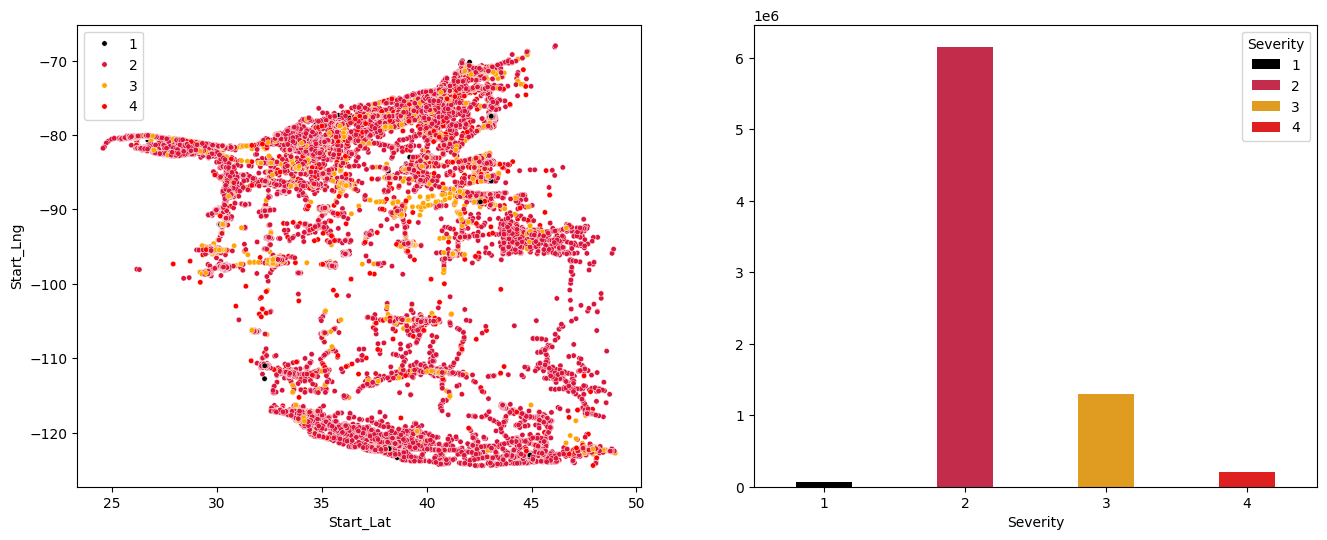

In [19]:
s= np.random.randint(0,df.shape[0],int(df.shape[0]/100))
fig ,ax = plt.subplots(1,2,figsize=(16,6))
plt.subplots_adjust(wspace=0.2)
sns.scatterplot(
    x=df['Start_Lat'].iloc[s],
    y=df['Start_Lng'].iloc[s],
    hue=df['Severity'].iloc[s],
    palette=['black','crimson','orange','red'],
    s=15,   # for point size in graph
    ax=ax[0]
)
sns.barplot(x=severities.index,y=severities.values,hue=severities.index,palette=['black','crimson','orange','red'],ax=ax[1],width=0.4)
ax[0].legend(loc = 'upper left')
plt.show()

Feature Creation --> Accident duration (hr)

In [20]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'] , format ='mixed')
df['End_Time'] = pd.to_datetime(df['End_Time'] , format = 'mixed')

df['Accident_duration_hr'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 3600

In [21]:
df[['Start_Time','End_Time','Accident_duration_hr']].sample(5)

,Start_Time,End_Time,Accident_duration_hr
7716669,2019-07-30 07:35:14,2019-07-30 08:04:49,0.493056
7221709,2020-02-21 18:48:00,2020-02-21 19:17:26,0.490556
7323693,2019-11-07 01:20:00,2019-11-07 02:32:15,1.204167
7554258,2018-03-10 13:43:10,2018-03-10 19:43:10,6.000000
2588693,2018-09-21 12:41:40,2018-09-21 13:11:16,0.493333


In [22]:
def random_imputation(column):
    non_missing = column.dropna().values
    return column.apply(lambda x: np.random.choice(non_missing) if pd.isna(x) else x)

Column--> Temperature(F)

In [23]:
df['Temperature'] = random_imputation(df['Temperature(F)'])

In [24]:
print(df['Temperature'].var())
print(df['Temperature(F)'].var())

361.5260555915239
361.5190114738906


There is a slight difference in variance whenever we do random imputation as you can see in above results but it will not impact it much .

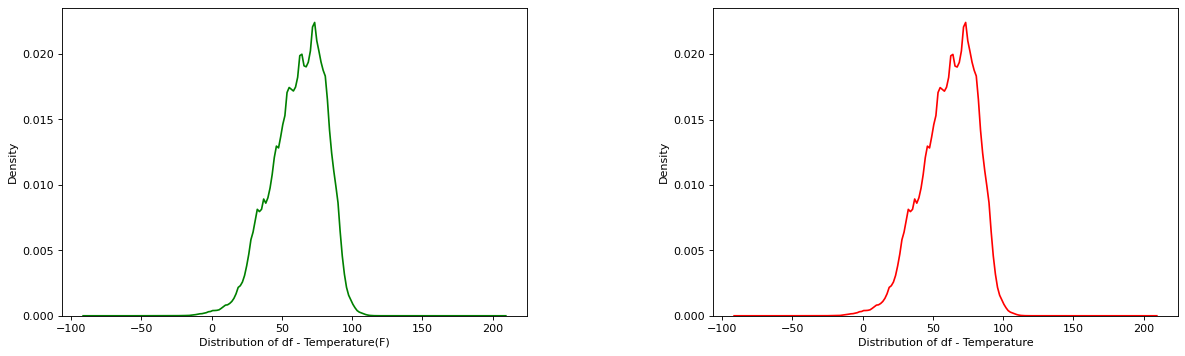

In [25]:
fig , ax = plt.subplots(1,2,figsize=(18,5),dpi=80)
plt.subplots_adjust(wspace=0.4)
sns.kdeplot(df['Temperature(F)'],label='original',color='green',ax=ax[0])
ax[0].set_xlabel('Distribution of df - Temperature(F)')
sns.kdeplot(df['Temperature'],color='Red',ax=ax[1])
ax[1].set_xlabel('Distribution of df - Temperature')
plt.show()

Column --> Wind_Speed(mph) 

In [26]:
print(f"Total missing value in wind speed col :{df['Wind_Speed(mph)'].isna().sum()}")
print(f"Missing value of wind speed when wind direction is 'calm' :{df.loc[df['Wind_Direction']=='Calm','Wind_Speed(mph)'].isna().sum()}")

print('Trying to find out mean of wind speed when direction is calm : ',df.loc[(df['Wind_Direction']=='Calm') & (df['Wind_Speed(mph)'].notna()), 'Wind_Speed(mph)'].mean())

# by here we can conclude that out of missing values in wind speed most them are at time when the direction is calm . This interpret that we have to fill some constant value in their.

Total missing value in wind speed col :571233
Missing value of wind speed when wind direction is 'calm' :368557
Trying to find out mean of wind speed when direction is calm :  nan


In [27]:
df.loc[df['Wind_Direction']=='CALM'].isna().sum()

ID                            0
Source                        0
Severity                      0
Start_Time                    0
End_Time                      0
Start_Lat                     0
Start_Lng                     0
End_Lat                  303380
End_Lng                  303380
Distance(mi)                  0
Description                   0
Street                     1697
City                         38
County                        0
State                         0
Zipcode                       0
Country                       0
Timezone                      0
Airport_Code                  0
Weather_Timestamp             0
Temperature(F)             5482
Wind_Chill(F)              5482
Humidity(%)                7686
Pressure(in)                999
Visibility(mi)             3871
Wind_Direction                0
Wind_Speed(mph)               0
Precipitation(in)         38432
Weather_Condition          3257
Amenity                       0
Bump                          0
Crossing

In [28]:
df.loc[df['Wind_Direction'] == 'calm', 'Wind_Direction'] = 'Calm'

In [29]:
df['Wind_Direction'].value_counts()

Wind_Direction
CALM        961624
S           419989
SSW         384840
W           383913
WNW         378781
NW          369352
Calm        368557
SW          364470
WSW         353806
SSE         349110
NNW         333427
N           307151
SE          294901
E           278914
ESE         268311
NE          258639
ENE         258474
NNE         255311
VAR         250566
South       177375
West        164751
North       153385
Variable    113996
East        103545
Name: count, dtype: int64

In [30]:
df.loc[df['Wind_Direction']=='Calm','Wind_Speed(mph)']=0.00

Because of pattern absencies in data we don't applying random imputation but instead we go for something constant for 'calm' wind direction and for else we do random imputation.

In [31]:
(df['Wind_Speed(mph)'] > 1.15).value_counts()

Wind_Speed(mph)
True     6195323
False    1533071
Name: count, dtype: int64

In [32]:
df.loc[
    (df['Wind_Direction'] == 'CALM') & (df['Wind_Speed(mph)'].notna()),
    'Wind_Speed(mph)'
].sample(5)

5883446    0.0
7185789    0.0
5585838    0.0
5005502    0.0
581936     0.0
Name: Wind_Speed(mph), dtype: float64

368557 + 961624 = 1330181 ~ 1533071   ---> by this we can say that wind speed at 'calm' wind direction is somewhere aound 1.15 mph 

In [33]:
non_calm = df.loc[df['Wind_Speed(mph)']>0]['Wind_Speed(mph)']
low = non_calm.quantile(0.05)
high = df['Wind_Speed(mph)'].quantile(0.95)
print(low,high)

3.0 17.0


In [34]:
df.loc[df['Wind_Speed(mph)'].isna(),'Wind_Speed(mph)'] = np.random.uniform(low,high,df['Wind_Speed(mph)'].isna().sum())

Column --> Wind_Direction

In [35]:
df['Wind_Direction'] = df['Wind_Direction'].fillna('Unknown')

Column --> Weather_Condition

In [36]:
df['Weather_Condition'].str.upper().unique()

array(['LIGHT RAIN', 'OVERCAST', 'MOSTLY CLOUDY', 'RAIN', 'LIGHT SNOW',
       'HAZE', 'SCATTERED CLOUDS', 'PARTLY CLOUDY', 'CLEAR', 'SNOW',
       'LIGHT FREEZING DRIZZLE', 'LIGHT DRIZZLE', 'FOG', 'SHALLOW FOG',
       'HEAVY RAIN', 'LIGHT FREEZING RAIN', 'CLOUDY', 'DRIZZLE', nan,
       'LIGHT RAIN SHOWERS', 'MIST', 'SMOKE', 'PATCHES OF FOG',
       'LIGHT FREEZING FOG', 'LIGHT HAZE', 'LIGHT THUNDERSTORMS AND RAIN',
       'THUNDERSTORMS AND RAIN', 'FAIR', 'VOLCANIC ASH', 'BLOWING SAND',
       'BLOWING DUST / WINDY', 'WIDESPREAD DUST', 'FAIR / WINDY',
       'RAIN SHOWERS', 'MOSTLY CLOUDY / WINDY', 'LIGHT RAIN / WINDY',
       'HAIL', 'HEAVY DRIZZLE', 'SHOWERS IN THE VICINITY', 'THUNDERSTORM',
       'LIGHT RAIN SHOWER', 'LIGHT RAIN WITH THUNDER',
       'PARTLY CLOUDY / WINDY', 'THUNDER IN THE VICINITY', 'T-STORM',
       'HEAVY THUNDERSTORMS AND RAIN', 'THUNDER', 'HEAVY T-STORM',
       'FUNNEL CLOUD', 'HEAVY T-STORM / WINDY', 'BLOWING SNOW',
       'LIGHT THUNDERSTORMS AND SNOW',

In [37]:
df['Weather_Condition'] = df['Weather_Condition'].fillna('Unknown')

Column --> Wind_Chill(F)

In [38]:
df.select_dtypes(include='number').corr()['Wind_Chill(F)'] 

Severity               -0.070039
Start_Lat              -0.480296
Start_Lng              -0.031810
End_Lat                -0.489578
End_Lng                 0.006733
Distance(mi)           -0.044309
Temperature(F)          0.993744
Wind_Chill(F)           1.000000
Humidity(%)            -0.314731
Pressure(in)            0.086598
Visibility(mi)          0.234022
Wind_Speed(mph)        -0.043008
Precipitation(in)      -0.012143
Accident_duration_hr    0.005214
Temperature             0.993744
Name: Wind_Chill(F), dtype: float64

In [39]:
mask = df['Temperature(F)'].notna() & df['Wind_Chill(F)'].notna()
val_mean = (df.loc[mask,'Temperature(F)'] - df.loc[mask,'Wind_Chill(F)']).mean()
val_var = (df.loc[mask,'Temperature(F)'] - df.loc[mask,'Wind_Chill(F)']).var()
print(f"val_mean : {val_mean}")
print(f"val_var : {val_var}")

val_mean : 1.611765506708847
val_var : 11.997104514203166


Temperature(F) is about 1.6°F higher than Wind_chill(F) but it also can vary around ±3.5°F

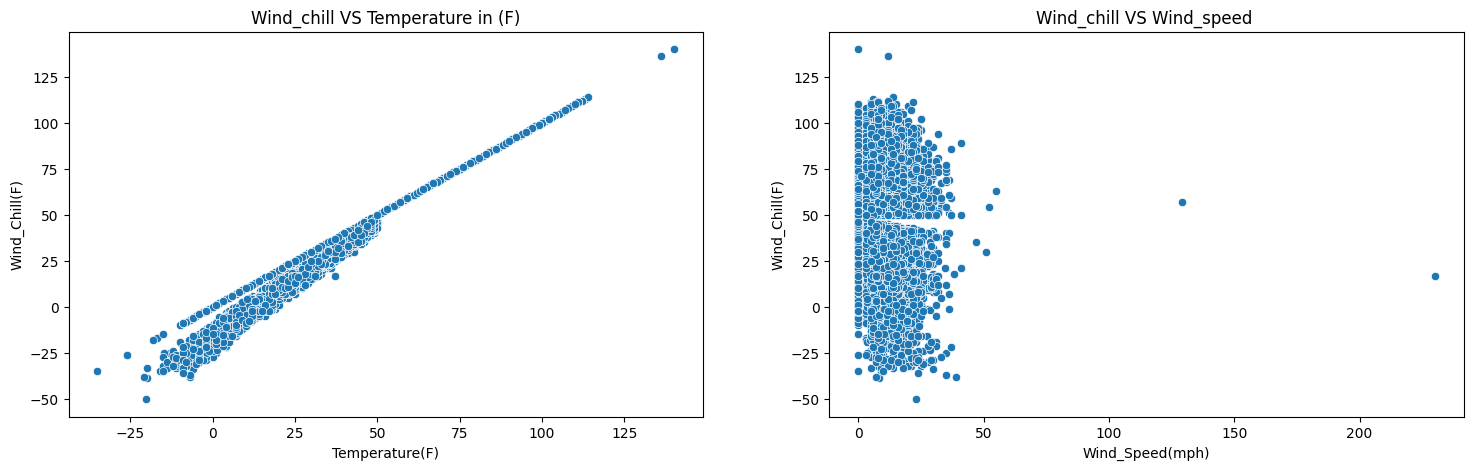

In [40]:
s = np.random.choice(df.index, int(df.shape[0]/100), replace=False)
fig , ax = plt.subplots(1,2,figsize=(18,5))
plt.subplots_adjust(wspace=0.2)
sns.scatterplot(x=df['Temperature(F)'].iloc[s],y=df['Wind_Chill(F)'].iloc[s],ax=ax[0])
ax[0].set_title("Wind_chill VS Temperature in (F)")
sns.scatterplot(x=df['Wind_Speed(mph)'].iloc[s],y=df['Wind_Chill(F)'].iloc[s],ax=ax[1])
ax[1].set_title("Wind_chill VS Wind_speed ")
plt.show()

use ml model for wind_chill with feature wind_speed and temperature

In [41]:
mask = df['Wind_Chill(F)'].notna()

In [42]:
X = df.loc[mask,['Temperature' , 'Wind_Speed(mph)']]
y = df.loc[mask,['Wind_Chill(F)']]
X_train , X_test , y_train, y_test = train_test_split(X,y,train_size=0.8)
lr= LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
print(f"r2_score : {r2_score(y_test,y_pred)}")

r2_score : 0.9909149436228942


In [43]:
poly = PolynomialFeatures(degree = 2)
X_poly = poly.fit_transform(df.loc[mask ,['Temperature', 'Wind_Speed(mph)']])
X_train , X_test , y_train, y_test = train_test_split(X_poly,y,train_size=0.8)
lr1= LinearRegression()
lr1.fit(X_train,y_train)
y_pred = lr1.predict(X_test)
print(f"r2_score for ploynomial(degree = 2): {r2_score(y_test,y_pred)}")

r2_score for ploynomial(degree = 2): 0.9968955564857692


In [44]:
missing_mask = df['Wind_Chill(F)'].isna()
X_missing_poly = poly.transform(df.loc[missing_mask, ['Temperature','Wind_Speed(mph)']])
df.loc[missing_mask, 'Wind_Chill(F)'] = lr1.predict(X_missing_poly)
df['Wind_Chill(F)'].isna().sum()

np.int64(0)

Column --> Humidity(%) , Precipitation(in) , Pressure(in) , Visibility(mi)

In [45]:
cols = [
    'Temperature',
    'Wind_Speed(mph)',
    'Humidity(%)',
    'Pressure(in)',
    'Visibility(mi)',
    'Precipitation(in)'
]

corr = df[cols].corr()

corr

,Temperature,Wind_Speed(mph),Humidity(%),Pressure(in),Visibility(mi),Precipitation(in)
Temperature,1.000000,0.043467,-0.330939,0.108859,0.215729,-0.004642
Wind_Speed(mph),0.043467,1.000000,-0.185629,-0.057330,0.020339,0.020288
Humidity(%),-0.330939,-0.185629,1.000000,0.115573,-0.384261,0.076936
Pressure(in),0.108859,-0.057330,0.115573,1.000000,0.038161,0.016511
Visibility(mi),0.215729,0.020339,-0.384261,0.038161,1.000000,-0.119796
Precipitation(in),-0.004642,0.020288,0.076936,0.016511,-0.119796,1.000000


Use median values of pressure and precipitation since not much correaltion exist and random imputation adds noise in data.

In [46]:
si = SimpleImputer(strategy = 'median')
cols = ['Pressure(in)','Precipitation(in)']
df[cols] = si.fit_transform(df[cols])

In [47]:
features = [
    'Temperature',
    'Wind_Speed(mph)',
    'Pressure(in)',
    'Precipitation(in)',
    'Start_Lat',
    'Start_Lng'
]

target = 'Humidity(%)'

train_df = df[df[target].notna()]
test_df  = df[df[target].isna()]

train_df = train_df.sample(500000)
model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1
)

model.fit(train_df[features], train_df[target])

df.loc[df[target].isna(), target] = model.predict(test_df[features])

In [48]:
features_vis= [
    'Humidity(%)',   
    'Wind_Speed(mph)',
    'Pressure(in)',
    'Precipitation(in)',
    'Start_Lat',
    'Start_Lng'
]

target_vis = 'Visibility(mi)'

train_df = df[df[target_vis].notna()]
test_df = df[df[target_vis].isna()]
train_df = train_df.sample(600000)
model.fit(train_df[features_vis],train_df[target_vis])
df.loc[df[target_vis].isna(),target_vis] =model.predict(test_df[features_vis])

Column --> Sunrise_Sunset , Civil_Twilight , Nautical_Twilight , Astrnomical_Twilight

In [49]:
cols = ['Sunrise_Sunset','Civil_Twilight','Nautical_Twilight','Astronomical_Twilight']
df[cols]=df[cols].fillna('Unknown')

fetched the weather_condition column for precise analysis on weather with respect to accidents

In [50]:
arr = df['Weather_Condition'].value_counts()
len(arr)
print(arr.index[0])
count_Rain=0
for indexs in arr.index:
    vec = indexs.split()
    if 'Rain' in  vec:
        count_Rain+=1
        print(vec)
print(count_Rain)      
print(df['Weather_Condition'].isna().sum())

Fair
['Light', 'Rain']
['Rain']
['Heavy', 'Rain']
['Light', 'Rain', 'with', 'Thunder']
['Light', 'Rain', '/', 'Windy']
['Light', 'Thunderstorms', 'and', 'Rain']
['Light', 'Freezing', 'Rain']
['Heavy', 'Thunderstorms', 'and', 'Rain']
['Rain', '/', 'Windy']
['Thunderstorms', 'and', 'Rain']
['Heavy', 'Rain', '/', 'Windy']
['Light', 'Rain', 'Shower']
['Freezing', 'Rain']
['Light', 'Rain', 'Showers']
['Rain', 'Showers']
['Light', 'Freezing', 'Rain', '/', 'Windy']
['Rain', 'Shower']
['Freezing', 'Rain', '/', 'Windy']
['Light', 'Rain', 'Shower', '/', 'Windy']
['Heavy', 'Freezing', 'Rain']
['Heavy', 'Rain', 'Showers']
['Rain', 'Shower', '/', 'Windy']
['Heavy', 'Rain', 'Shower']
['Rain', 'and', 'Sleet']
['Heavy', 'Freezing', 'Rain', '/', 'Windy']
['Heavy', 'Rain', 'Shower', '/', 'Windy']
26
0


In [51]:
def process_weather(df, col='Weather_Condition'):
    
    
    w = df[col].fillna('').str.upper()

     
    df['is_clear'] = w.str.contains(r'\bCLEAR\b|\bFAIR\b').astype(int)

    df['is_cloud'] = w.str.contains(r'CLOUD|OVERCAST').astype(int)

    df['is_rain'] = w.str.contains(r'RAIN|DRIZZLE|SHOWERS').astype(int)

    df['is_snow'] = w.str.contains(r'SNOW').astype(int)

    df['is_sleet_ice'] = w.str.contains(r'SLEET|ICE PELLETS|FREEZING').astype(int)

    df['is_fog_haze'] = w.str.contains(r'FOG|HAZE|MIST').astype(int)

    df['is_thunder'] = w.str.contains(r'THUNDER|T-STORM').astype(int)

    df['is_windy'] = w.str.contains(r'WINDY').astype(int)

    df['is_hail'] = w.str.contains(r'HAIL').astype(int)

    df['is_dust_smoke'] = w.str.contains(r'DUST|SAND|SMOKE|ASH').astype(int)

    # --- Step 3: SEVERE WEATHER FLAG ---
    
    # condition 1: inherently severe
    cond1 = w.str.contains(r'TORNADO|THUNDER|T-STORM|SQUALL')

    # condition 2: heavy precipitation
    cond2 = (
        w.str.contains(r'HEAVY') &
        w.str.contains(r'RAIN|SNOW|SLEET|ICE')
    )

    # condition 3: dangerous visibility
    cond3 = (
        w.str.contains(r'FOG|HAZE|SMOKE|DUST|SAND') &
        w.str.contains(r'HEAVY|DENSE|WIDESPREAD|BLOWING')
    )

    # condition 4: freezing (road danger)
    cond4 = w.str.contains(r'FREEZING')

    df['is_severe_weather'] = (cond1 | cond2 | cond3 | cond4).astype(int)

    return df

In [52]:
df= process_weather(df)

In [53]:
df.loc[df['Weather_Condition']=='Wintry Mix','is_severe_weather'] = 1

In [54]:
df.loc[:,['Weather_Condition','is_clear','is_cloud','is_rain','is_snow','is_sleet_ice','is_fog_haze','is_thunder','is_windy','is_dust_smoke','is_severe_weather','is_hail']].sample(10)

,Weather_Condition,is_clear,is_cloud,is_rain,is_snow,is_sleet_ice,is_fog_haze,is_thunder,is_windy,is_dust_smoke,is_severe_weather,is_hail
6732836,Fair,1,0,0,0,0,0,0,0,0,0,0
4809885,Fair,1,0,0,0,0,0,0,0,0,0,0
6140465,Fair,1,0,0,0,0,0,0,0,0,0,0
7626544,Clear,1,0,0,0,0,0,0,0,0,0,0
2604765,Overcast,0,1,0,0,0,0,0,0,0,0,0
4233413,Partly Cloudy / Windy,0,1,0,0,0,0,0,1,0,0,0
1308988,Cloudy,0,1,0,0,0,0,0,0,0,0,0
3119327,Scattered Clouds,0,1,0,0,0,0,0,0,0,0,0
4962620,Partly Cloudy,0,1,0,0,0,0,0,0,0,0,0
2887174,Clear,1,0,0,0,0,0,0,0,0,0,0


In [55]:
cols = ['is_clear','is_cloud','is_rain','is_snow','is_sleet_ice',
        'is_fog_haze','is_thunder','is_windy','is_dust_smoke',
        'is_severe_weather','is_hail']

df.loc[(df[cols] == 0).all(axis=1), 'Weather_Condition'].unique()


array(['Unknown', 'N/A Precipitation'], dtype=object)

ANALYSIS

In [56]:
df['Month']=df['Start_Time'].dt.month_name()
df['Weekday']=df['Start_Time'].dt.day_name()

In [57]:
def classify_period(hour, minute):
    total = hour * 60 + minute

    if 330 <= total < 360:        # 5:30–6:00
        return 'Early Morning'
    elif 360 <= total < 720:      # 6:00–12:00
        return 'Morning'
    elif 720 <= total < 1080:     # 12:00–18:00
        return 'Afternoon'
    elif 1080 <= total < 1320:    # 18:00–22:00
        return 'Evening'
    else:
        return 'Night'

df['Period'] = df['Start_Time'].apply(lambda x: classify_period(x.hour, x.minute))

C:\Users\Aditya Mishra\AppData\Local\Temp\ipykernel_22312\647372721.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(counts_m.index,rotation=60)
C:\Users\Aditya Mishra\AppData\Local\Temp\ipykernel_22312\647372721.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(counts_wd.index,rotation=60)
C:\Users\Aditya Mishra\AppData\Local\Temp\ipykernel_22312\647372721.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(counts_pd.index,rotation=60)


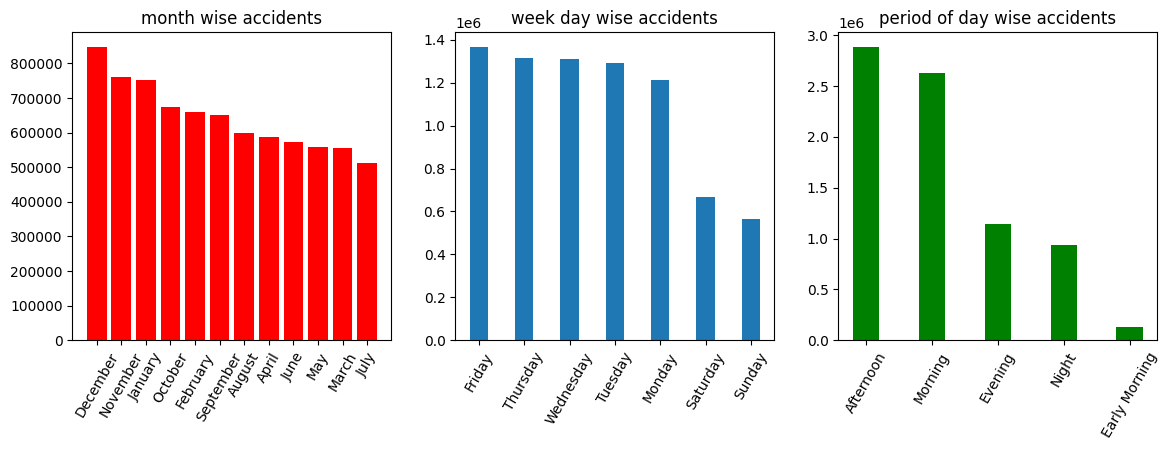

In [58]:
counts_m = df['Month'].value_counts()
counts_wd = df['Weekday'].value_counts()
counts_pd = df['Period'].value_counts()
fig , ax = plt.subplots(1,3,figsize=(14,4))
plt.subplots_adjust(wspace=0.2)
ax[0].bar(counts_m.index,counts_m.values,color='red')
ax[0].set_title('month wise accidents')
ax[0].set_xticklabels(counts_m.index,rotation=60)

ax[1].bar(counts_wd.index,counts_wd.values,width=0.4)
ax[1].set_title('week day wise accidents')
ax[1].set_xticklabels(counts_wd.index,rotation=60)

ax[2].bar(counts_pd.index,counts_pd.values,color='green',width=0.4)
ax[2].set_title('period of day wise accidents')
ax[2].set_xticklabels(counts_pd.index,rotation=60)

plt.show()

“Accident patterns exhibit strong temporal dependence, with higher occurrences during winter months, weekdays (especially Fridays), and peak traffic periods such as afternoons and mornings. These trends highlight the combined influence of environmental conditions and traffic density on accident frequency.”

In [59]:
means   = []
medians = []
modes   = []
vars_   = []
stds    = []

for i in range(1, 5):
    temp = df.loc[df['Severity'] == i, 'Distance(mi)']
    
    means.append(temp.mean())
    medians.append(temp.median())
    modes.append(temp.mode()[0])   # mode can return multiple values
    vars_.append(temp.var())
    stds.append(temp.std())

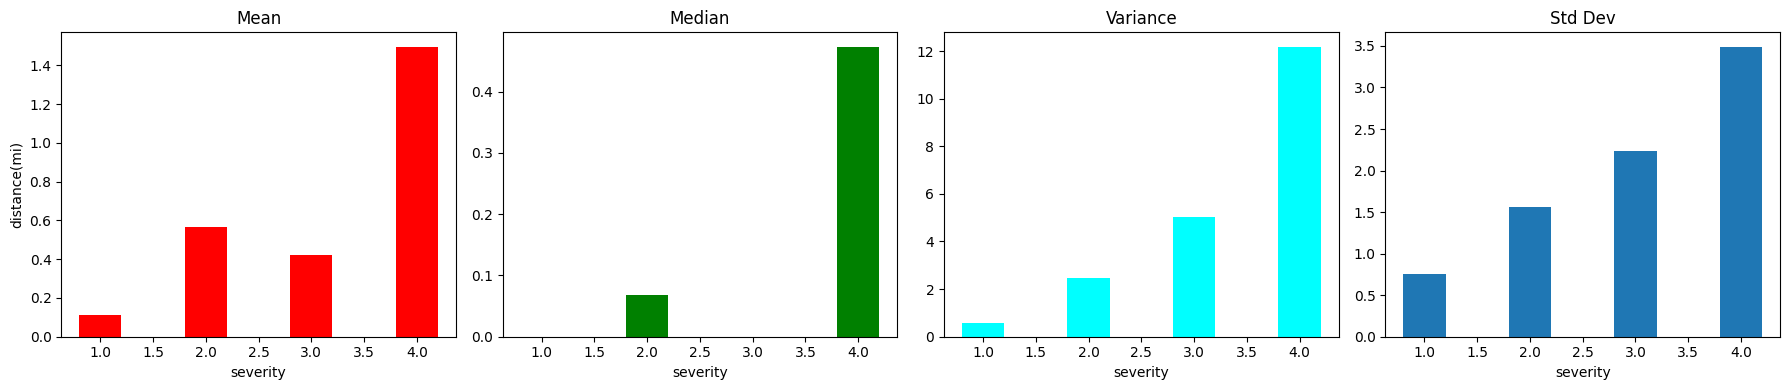

In [60]:
fig, ax = plt.subplots(1, 4, figsize=(18, 4))

severity = [1, 2, 3, 4]

ax[0].bar(severity, means,color='red',width=0.4)
ax[0].set_title("Mean")
ax[0].set_xlabel('severity')
ax[0].set_ylabel('distance(mi)')

ax[1].bar(severity, medians,color='green',width=0.4)
ax[1].set_title("Median")
ax[1].set_xlabel('severity')

ax[2].bar(severity, vars_,color='cyan',width=0.4)
ax[2].set_title("Variance")
ax[2].set_xlabel('severity')

ax[3].bar(severity, stds,width=0.4)
ax[3].set_title("Std Dev")
ax[3].set_xlabel('severity')

plt.tight_layout()
plt.show()

“Analysis shows that accident distance increases with severity, with severe accidents (level 4) having significantly higher mean and median distances. The large gap between mean and median for lower severity levels indicates a highly skewed distribution, where most accidents affect short distances but a few outliers extend over large areas. Additionally, variance and standard deviation increase with severity, suggesting that higher severity accidents are more unpredictable in terms of spatial impact.”

In [61]:
val= df['Distance(mi)'].mean()
counts_end_lat_long_miss = df[(df['Severity']==4) & (df['Distance(mi)']>val)]['End_Lat'].isna().sum()
print('Counts where the severity is high and distance is large(comparatively) and end_lat is nan : ',counts_end_lat_long_miss)
print('Total nan values in End_lat : ',df['End_Lat'].isna().sum())

Counts where the severity is high and distance is large(comparatively) and end_lat is nan :  12093
Total nan values in End_lat :  3402762


find out which city and state has major accidents 

In [62]:
len(df['City'].unique())

13679

In [63]:
counts = df['City'].value_counts()
valid_cities = counts[counts < 1000].index
df_filtered = df[df['City'].isin(valid_cities)]
len(df_filtered['City'].value_counts())

12460

In [64]:
len(df['County'].unique())

1871

In [65]:
counts_county = df['County'].value_counts()
valid_counties = counts_county[(counts_county < 10000) & (counts_county > 5000)].index
df_filtered_county = df[df['County'].isin(valid_counties)]
len(df_filtered_county['County'].value_counts())

92

In [66]:
def create_city_features(df):
    
    city_counts = df['City'].value_counts()    
    df['City_Accident_Count'] = df['City'].map(city_counts)
    df['City_Log_Count'] = np.log1p(df['City_Accident_Count'])
    
    # Step 4: logical categorization (based on your idea)
    def categorize(val):
        if val < 1000:
            return 1   # very low
        elif val < 10000:
            return 2   # low
        elif val < 25000:
            return 3   # medium
        elif val < 100000:
            return 4   # high
        else:
            return 5   # very high
    
    df['City_Category'] = df['City_Accident_Count'].apply(categorize)
    
    return df

In [67]:
def create_county_features(df):
    
    county_counts = df['County'].value_counts()    
    df['County_Accident_Count'] = df['County'].map(county_counts)
    df['County_Log_Count'] = np.log1p(df['County_Accident_Count'])
    
    # Step 4: logical categorization (based on your idea)
    def categorize(val):
        if val < 1000:
            return 1   # very low
        elif val < 10000:
            return 2   # low
        elif val < 25000:
            return 3   # medium
        elif val < 100000:
            return 4   # high
        else:
            return 5   # very high
    
    df['County_Category'] = df['County_Accident_Count'].apply(categorize)
    
    return df

In [68]:
df = create_county_features(df)
df =df.drop(columns=['County_Accident_Count'])

In [69]:
df = create_city_features(df)
df = df.drop(columns=['City_Accident_Count'])

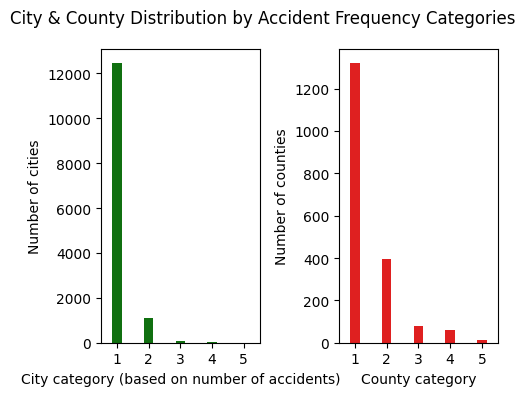

In [70]:
county_counts = df.groupby('County_Category')['County'].nunique()
city_counts = df.groupby('City_Category')['City'].nunique()
fig, ax = plt.subplots(1, 2, figsize=(5,4))
sns.barplot(
    x=city_counts.index,
    y=city_counts.values,
    width=0.3,
    ax=ax[0],
    color='green'
)

sns.barplot(
    x=county_counts.index,
    y=county_counts.values,
    width=0.3,
    ax=ax[1],
    color='red'
)
ax[0].set_xlabel('City category (based on number of accidents)')  # more the value of category it falls into the higher the number of accidents it has
ax[0].set_ylabel('Number of cities')

ax[1].set_xlabel('County category')
ax[1].set_ylabel('Number of counties')

plt.suptitle("City & County Distribution by Accident Frequency Categories")
plt.tight_layout()
plt.show()

“The distribution shows that the majority of both cities and counties fall into Category 1, indicating that most regions experience relatively low accident frequencies, with only a small number of locations contributing to higher accident counts.”

In [71]:
df['County'].nunique()

1871

In [72]:
county_n=df.loc[df['County_Category']==5,'County'].unique()
county_n

array(['Montgomery', 'Los Angeles', 'Orange', 'San Diego',
       'San Bernardino', 'Miami-Dade', 'Harris', 'Dallas', 'Travis',
       'Mecklenburg', 'Wake', 'Maricopa'], dtype=object)

In [73]:
df.loc[df['City'].isna(),'City_Category'] = 0

In [74]:
city_n=df.loc[df['City_Category']==5,'City'].unique()
city_n

array(['Los Angeles', 'Miami', 'Orlando', 'Dallas', 'Charlotte',
       'Houston'], dtype=object)

In [75]:
city = ['Los Angeles', 'Miami', 'Orlando', 'Dallas', 'Charlotte', 'Houston']
df1 = df[df['City'].isin(city)]
df1['Year'] = df1['Start_Time'].dt.year
temp = df1.groupby(['City','Year','Month']).size().reset_index(name='count')
ans = temp.loc[temp.groupby(['City','Year'])['count'].idxmax()]

C:\Users\Aditya Mishra\AppData\Local\Temp\ipykernel_22312\2342890762.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Year'] = df1['Start_Time'].dt.year


In [76]:
print(type(ans))
print(ans.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['City', 'Year', 'Month', 'count'], dtype='object')


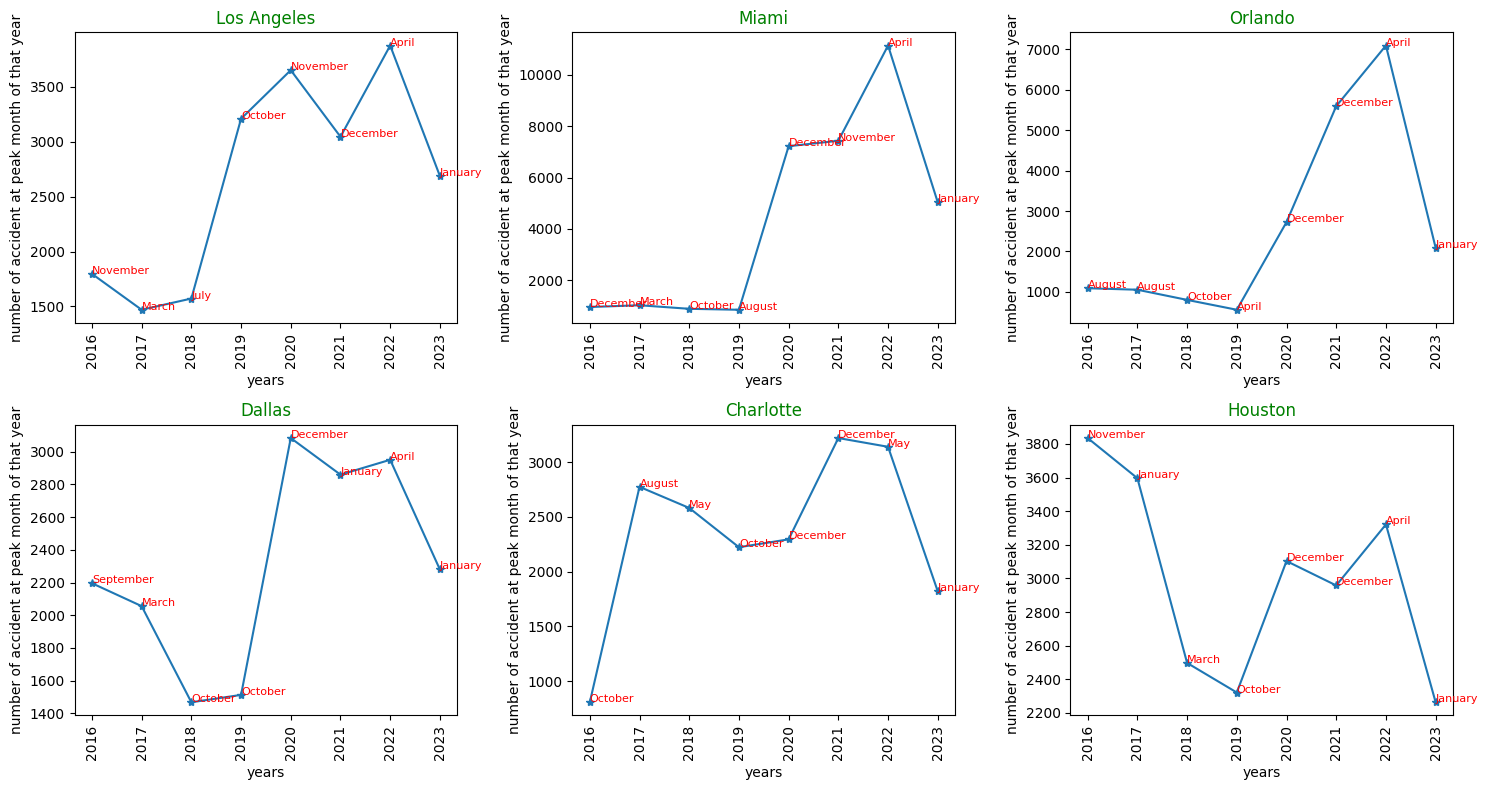

In [77]:
fig, ax = plt.subplots(2, 3, figsize=(15,8))
for i in range(len(city)):
    figs = ans[ans['City'] == city[i]]
    r = i // 3   
    c = i % 3 
    for j in range(len(figs)):
        ax[r][c].text(
            figs['Year'].iloc[j],
            figs['count'].iloc[j],
            figs['Month'].iloc[j],
            fontsize=8,
            color='red'
        )
    ax[r][c].plot(figs['Year'], figs['count'],marker='*')
    ax[r][c].set_title(city[i],color='green')
    ax[r][c].set_xlabel('years')
    ax[r][c].set_ylabel('number of accident at peak month of that year')
    ax[r][c].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

The plots illustrate yearly trends for selected high-accident cities, where each point represents the peak month (the month with the highest number of accidents) in a given year, along with its corresponding accident count.

In [78]:
county = ['Montgomery', 'Los Angeles', 'Orange', 'San Diego',
       'San Bernardino', 'Miami-Dade', 'Harris', 'Dallas', 'Travis',
       'Mecklenburg', 'Wake', 'Maricopa']
df2 = df[df['County'].isin(county)]
df2['Year'] = df2['Start_Time'].dt.year
temp1 = df2.groupby(['County','Year','Month']).size().reset_index(name='count')
ans1 = temp1.loc[temp1.groupby(['County','Year'])['count'].idxmax()]

C:\Users\Aditya Mishra\AppData\Local\Temp\ipykernel_22312\3778993341.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Year'] = df2['Start_Time'].dt.year


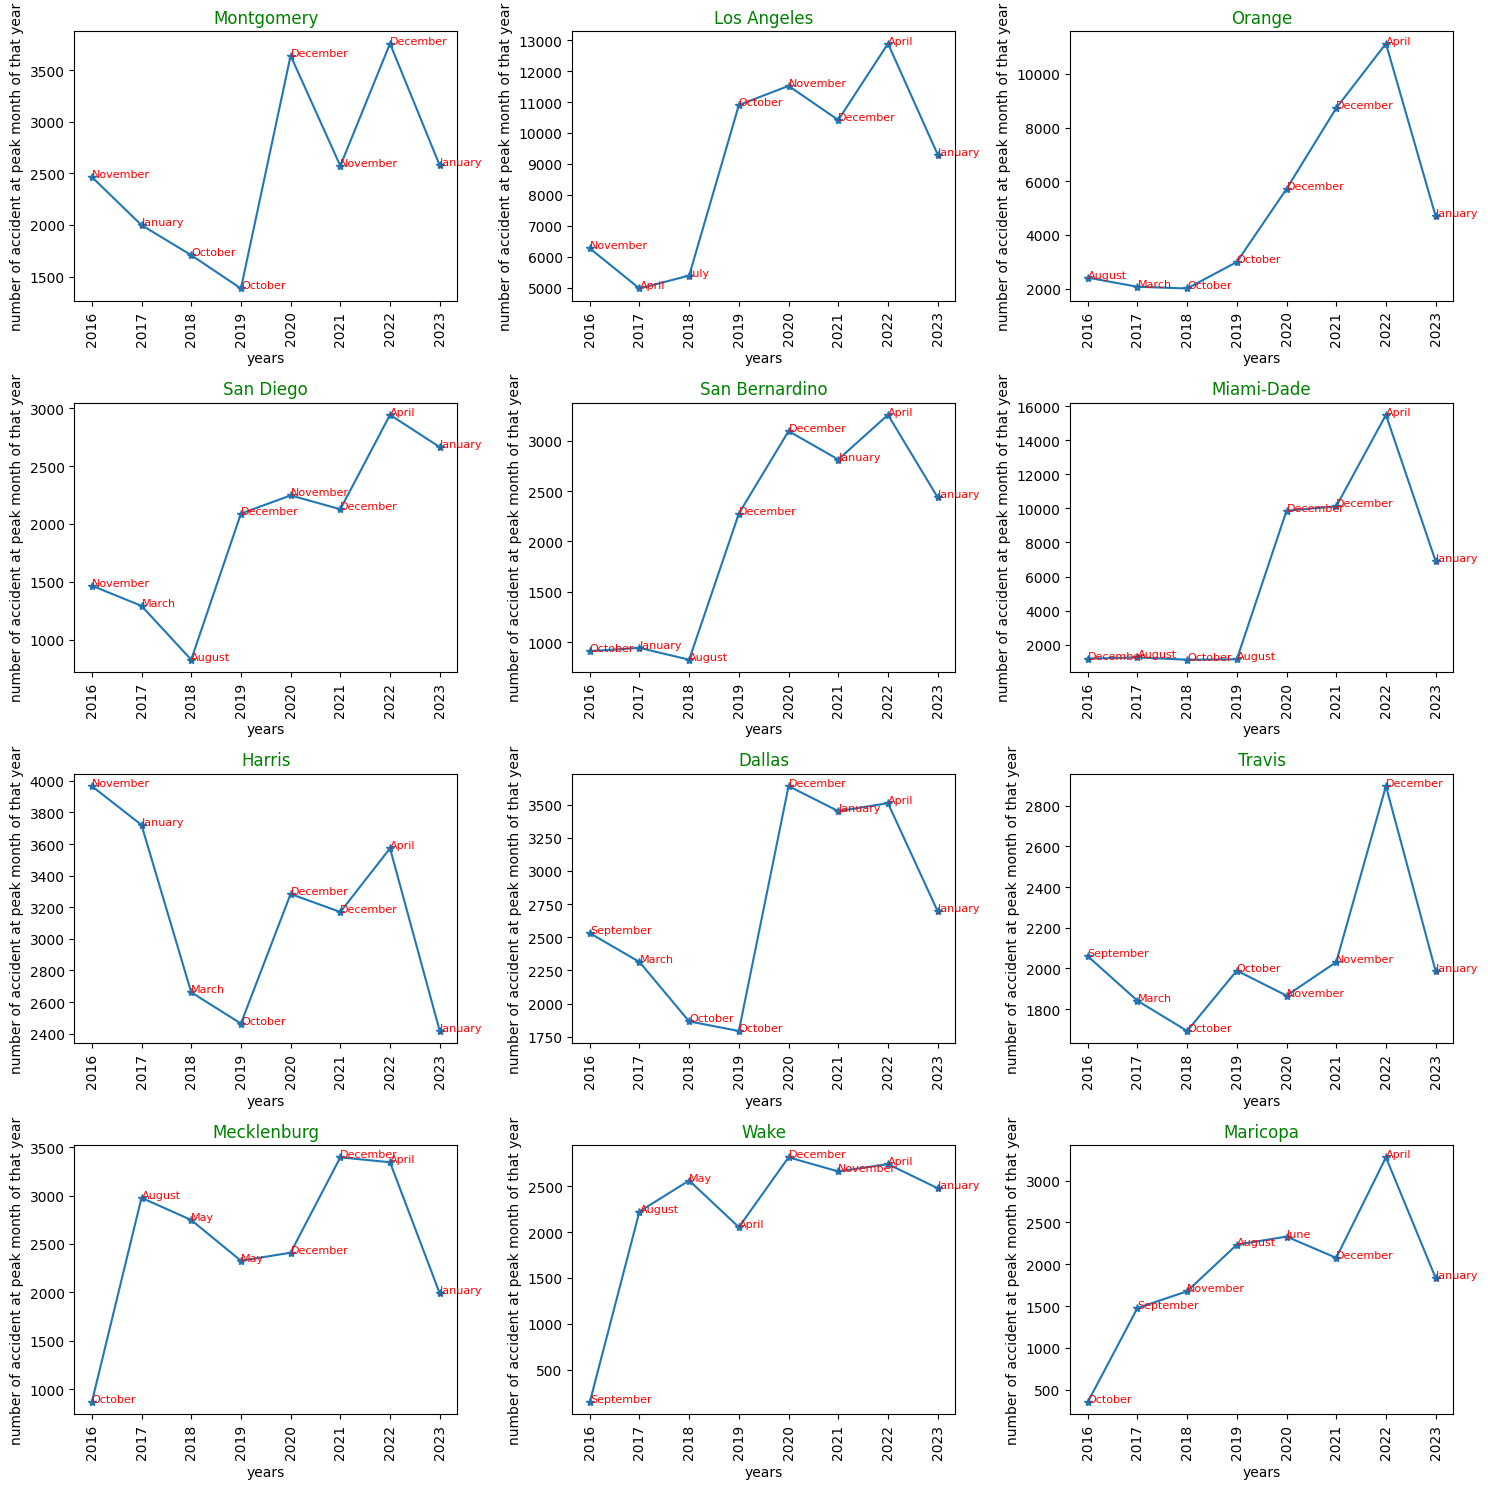

In [79]:
fig, ax = plt.subplots(4, 3, figsize=(15,15))
for i in range(len(county)):
    figs = ans1[ans1['County'] == county[i]]
    r = i // 3  
    c = i % 3
    for j in range(len(figs)):
        ax[r][c].text(
            figs['Year'].iloc[j],
            figs['count'].iloc[j],
            figs['Month'].iloc[j],
            fontsize=8,
            color='red'
        )
    ax[r][c].plot(figs['Year'], figs['count'],marker='*')
    ax[r][c].set_title(county[i],color='green')
    ax[r][c].set_xlabel('years')
    ax[r][c].set_ylabel('number of accident at peak month of that year')
    ax[r][c].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

The plots illustrate yearly trends for selected high-accident counties, where each point represents the peak month (the month with the highest number of accidents) in a given year, along with its corresponding accident count.

Every year which which has high and least accidents ?

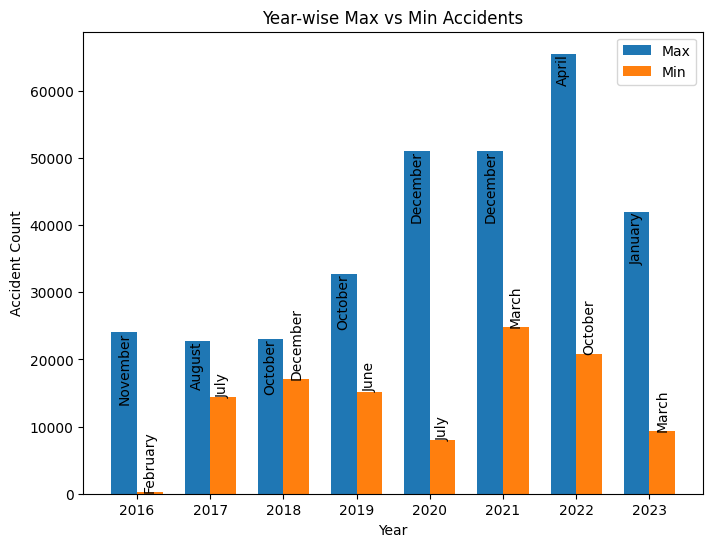

In [80]:
df_year_month = df2.groupby(['Year','Month']).size().reset_index(name='count')
df_year = df_year_month.groupby('Year')

years = []
max_counts = []
min_counts = []
max_months = []
min_months = []

for yr, data in df_year:
    
    max_row = data[data['count'] == data['count'].max()]
    min_row = data[data['count'] == data['count'].min()]
    
    years.append(yr)
    
    max_counts.append(max_row['count'].iloc[0])
    min_counts.append(min_row['count'].iloc[0])
    
    max_months.append(max_row['Month'].iloc[0])
    min_months.append(min_row['Month'].iloc[0])

x = np.arange(len(years))  
width = 0.35

plt.figure(figsize=(8,6))

plt.bar(x - width/2, max_counts, width, label='Max',)
plt.bar(x + width/2, min_counts, width, label='Min')

plt.xticks(x, years)
plt.xlabel('Year')
plt.ylabel('Accident Count')
plt.title('Year-wise Max vs Min Accidents')
for i in range(len(years)):
    plt.text(x[i] - width/2, max_counts[i], max_months[i],
             ha='center', va='top', fontsize=10, rotation=90)
    
    plt.text(x[i] + width/2, min_counts[i], min_months[i],
             ha='center', va='bottom', fontsize=10, rotation=90)

plt.legend()
plt.show()

 The chart shows a consistent increase in maximum accident counts from 2016 to 2022, indicating a rising trend in peak accident periods over the years. The highest spike is observed in 2022 (April), suggesting that this year had the most intense accident concentration in a single month.

On the other hand, minimum accident counts vary significantly across years, with some months like February (2016) and July (2020) showing notably low values. This variation indicates that while peak accidents are increasing, low-accident periods are not following a consistent trend.

Another important observation is that winter months (like December and January) frequently appear as peak accident months, which may be linked to adverse weather conditions such as fog or reduced visibility. However, in some years like 2022 (April), non-winter months also show high accident counts, suggesting that factors beyond weather—such as traffic volume or road conditions—also play a role.

Overall, the data suggests:

-> A growing trend in accident intensity over the years.
-> Seasonal patterns influencing accident peaks.
-> Irregular behavior in low-accident months, indicating multiple influencing factors.

Accidents nearby poi ?

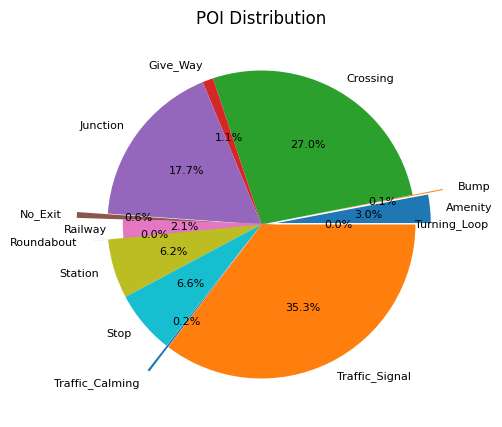

In [81]:
poi = [ 'Amenity','Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal','Turning_Loop']
poi_counts= df[poi].sum()
plt.figure(figsize=(5,5))
plt.pie(poi_counts, labels=poi, autopct='%1.1f%%',textprops={'fontsize':8},explode=[0.1, 0.2, 0, 0,0,0.2,-0.1,0.1,0,0,0.2,0,-0.1])
plt.title('POI Distribution')
plt.show()

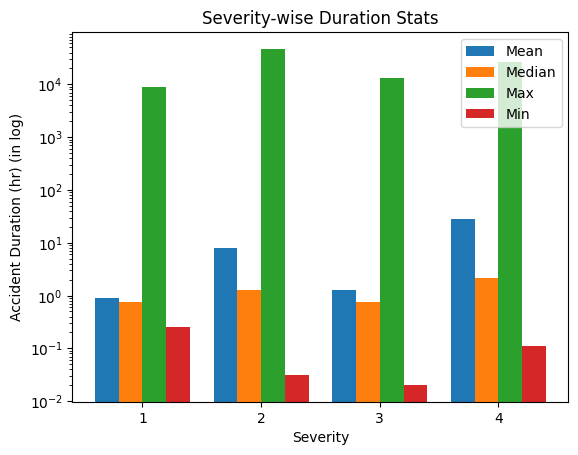

In [82]:
severities = [1,2,3,4]
mean_sev = []
median_sev = []
max_sev = []
min_sev = []
for i in severities:
    temp = df.loc[df['Severity']==i,'Accident_duration_hr']
    mean_sev.append(temp.mean())
    median_sev.append(temp.median())
    max_sev.append(temp.max())
    min_sev.append(temp.min())

x = np.arange(len(severities))

plt.figure()

plt.bar(x - 0.3, mean_sev, width=0.2, label='Mean')
plt.bar(x - 0.1, median_sev, width=0.2, label='Median')
plt.bar(x + 0.1, max_sev, width=0.2, label='Max')
plt.bar(x + 0.3, min_sev, width=0.2, label='Min')

plt.yscale('log') 

plt.xticks(x, severities)
plt.xlabel("Severity")
plt.ylabel("Accident Duration (hr) (in log)")  # time to clear the traffic..
plt.title("Severity-wise Duration Stats")

plt.legend()
plt.show()

Accident duration is not solely dependent on severity but also exhibits heavy-tailed behavior, indicating the presence of rare yet high-impact events that significantly influence overall statistics.

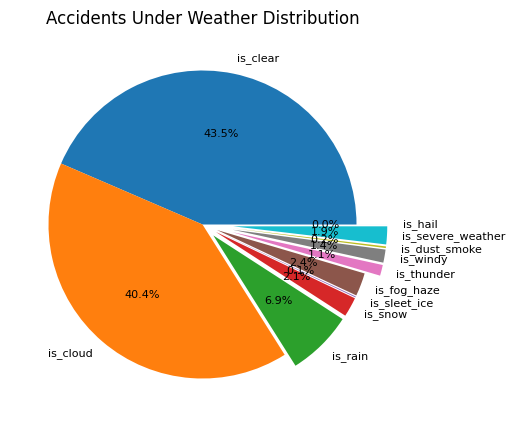

In [83]:
weather_cols = ['is_clear','is_cloud','is_rain','is_snow','is_sleet_ice','is_fog_haze','is_thunder','is_windy','is_dust_smoke','is_severe_weather','is_hail']
weather_counts = df[weather_cols].sum()
plt.figure(figsize=(5,5))
plt.pie(weather_counts, labels=weather_cols, autopct='%1.1f%%',textprops={'fontsize':8},explode=[0, 0, 0.1, 0.1,0.1,0.1,0.2,0.2,0.2,0.2,0.2])
plt.title('Accidents Under Weather Distribution')
plt.show()

In [84]:
weather = ['is_clear','is_cloud','is_rain','is_snow','is_sleet_ice',
           'is_fog_haze','is_thunder','is_windy','is_dust_smoke','is_hail']
df['Year'] =df['Start_Time'].dt.year
result = {}

for w in weather:
    temp = df[df[w] == 1].groupby('Year').size().reset_index(name='count')
    result[w] = temp

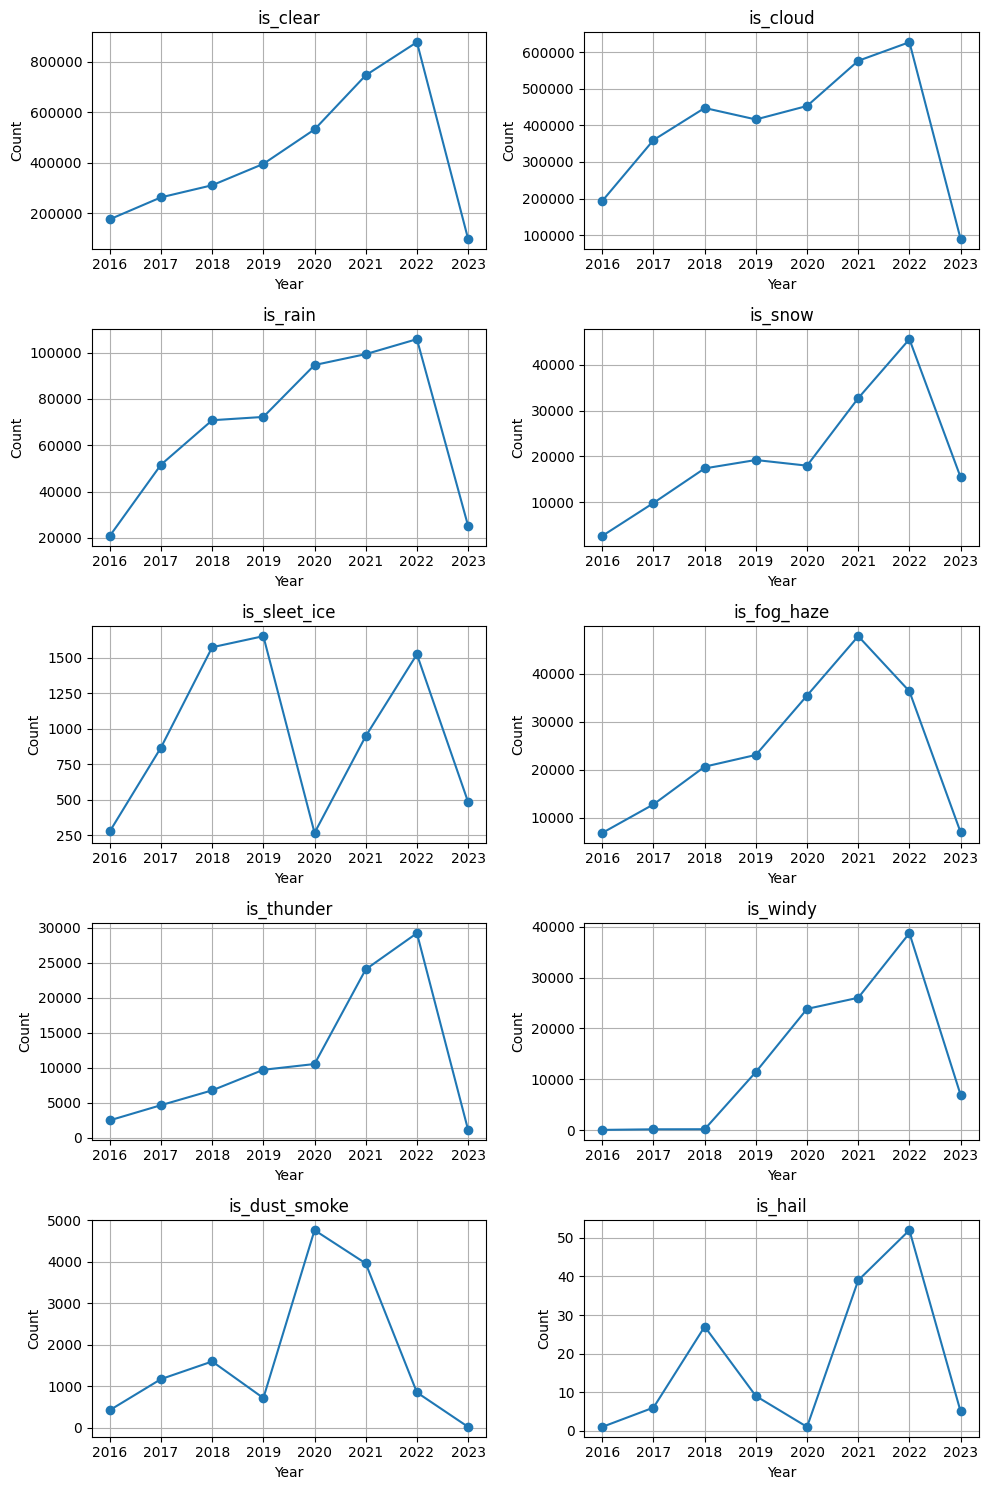

In [85]:
fig, axes = plt.subplots(5, 2, figsize=(10, 15))  # 10 plots (5x2)

axes = axes.flatten()  # make indexing easy

for i in range(len(weather)):
    w = weather[i]
    temp = result[w]
    
    axes[i].plot(temp['Year'], temp['count'], marker='o')
    axes[i].set_title(w)
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Count")
    axes[i].grid()

plt.tight_layout()
plt.show()

Accident occurrences across weather conditions show a general increasing trend from 2016 to 2022, followed by a sharp decline in 2023, likely due to incomplete data. Clear and cloudy conditions dominate accident counts, suggesting that higher exposure rather than adverse weather primarily drives accident frequency. In contrast, weather conditions such as rain exhibit steady growth, while snow and fog show irregular spikes, indicating seasonal or regional influences. Rare weather events like hail, dust, and sleet contribute minimally and display high variability, making them less reliable for predictive modeling.

In [86]:
top_cities = df['City'].value_counts().head(10).index
top_df = df[df['City'].isin(top_cities)]
weather = ['is_clear','is_cloud','is_rain','is_snow','is_sleet_ice',
           'is_fog_haze','is_thunder','is_windy','is_dust_smoke','is_hail']

result = {}

for w in weather:
    temp = top_df[top_df[w] == 1]['City'].value_counts()
    result[w] = temp

temp = top_df.melt(id_vars=['City'], value_vars=weather,
                   var_name='Weather', value_name='Flag')

temp = temp[temp['Flag'] == 1]

final = temp.groupby(['City','Weather']).size().reset_index(name='count')

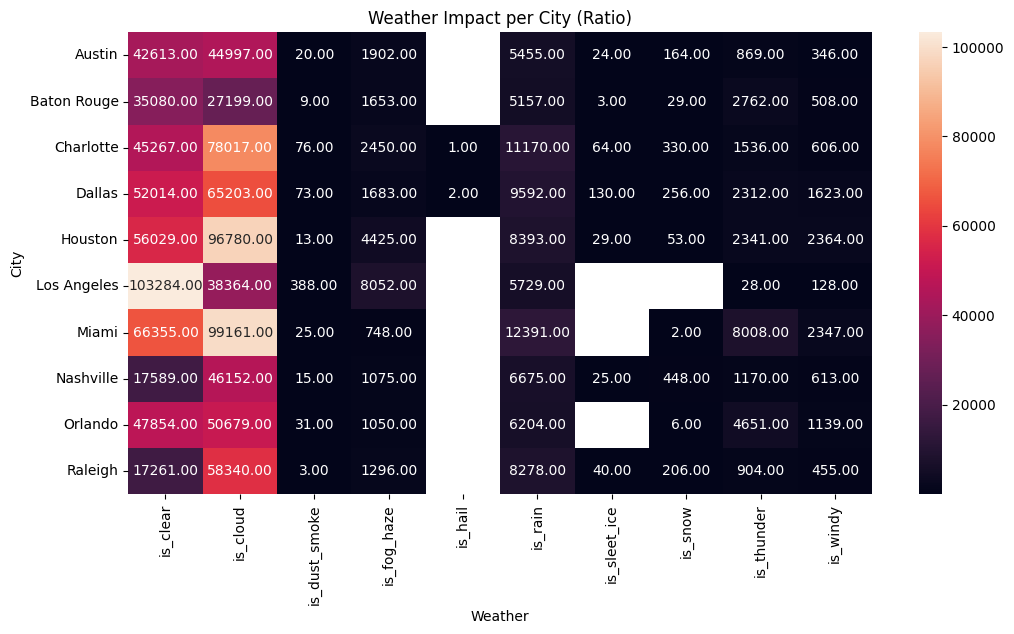

In [87]:
pivot = final.pivot(index='City', columns='Weather', values='count')

plt.figure(figsize=(12,6))

sns.heatmap(pivot, annot=True, fmt=".2f")

plt.title("Weather Impact per City (Ratio)")
plt.xlabel("Weather")
plt.ylabel("City")

plt.show()

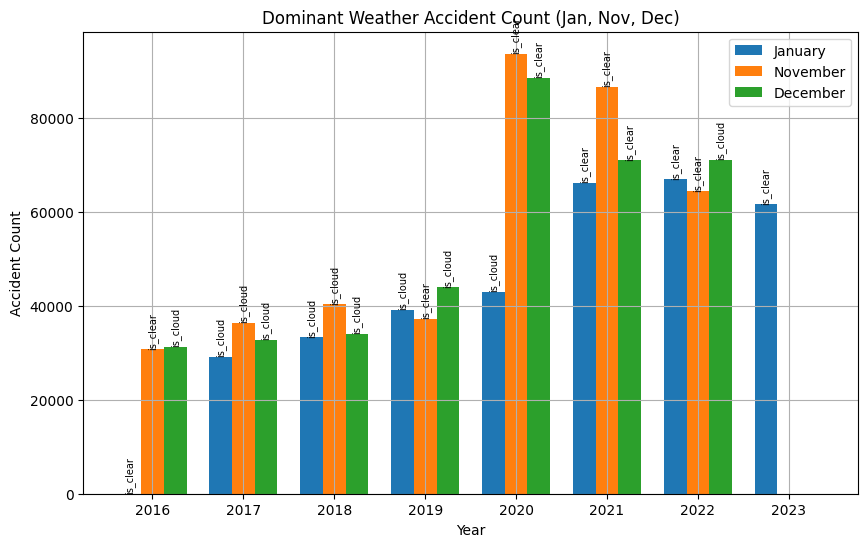

In [88]:
temp = df.melt(
    id_vars=['Year','Month'],
    value_vars=weather,
    var_name='Weather',
    value_name='Flag'
)

temp = temp[temp['Flag'] == 1]

temp = temp.groupby(['Year','Month','Weather']).size().reset_index(name='count')

months = ['January','November','December']
temp = temp[temp['Month'].isin(months)]

idx = temp.groupby(['Year','Month'])['count'].idxmax()
final = temp.loc[idx].reset_index(drop=True)
pivot = final.pivot(index='Year', columns='Month', values='count').fillna(0)

months = ['January','November','December']

x = np.arange(len(pivot.index))
bar_width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - bar_width, pivot['January'], width=bar_width, label='January')
plt.bar(x, pivot['November'], width=bar_width, label='November')
plt.bar(x + bar_width, pivot['December'], width=bar_width, label='December')

plt.xticks(x, pivot.index)
plt.xlabel("Year")
plt.ylabel("Accident Count")
plt.title("Dominant Weather Accident Count (Jan, Nov, Dec)")

plt.legend()
plt.grid()
for i in range(len(pivot.index)):
    year = pivot.index[i]
    
    for j, m in enumerate(months):
        row = final[(final['Year'] == year) & (final['Month'] == m)]
        
        if not row.empty:
            count = row['count'].values[0]
            weather_name = row['Weather'].values[0]
            
            xpos = x[i] + (j - 1) * bar_width
            plt.text(xpos, count, weather_name,
                     ha='center', va='bottom',
                     rotation=90, fontsize=7)
plt.show()

In [89]:
counts = df.loc[(df['is_clear']==1) & (df['Year']==2020) & (df['Month']=='November')].shape[0]
counts

93566

In [90]:
count = df.loc[(df['City_Log_Count'].isna())&(df['City'].isna())]
count.shape[0]

253

In [91]:
POI = ['Amenity','Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway','Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal','Turning_Loop']
weather_n = ['Humidity(%)', 'Pressure(in)', 'Visibility(mi)','Wind_Speed(mph)', 'Precipitation(in)','Temperature'] 
weather_c = ['is_clear', 'is_cloud', 'is_rain', 'is_snow', 'is_sleet_ice','is_fog_haze', 'is_thunder', 'is_windy', 'is_hail', 'is_dust_smoke','is_severe_weather']
time = ['Period','Month','Weekday']
lighting = ['Sunrise_Sunset']    # 'Civil_Twilight', 'Nautical_Twilight','Astronomical_Twilight' -->these might create data redundancy so go one by one
location = ['County_Log_Count', 'City_Log_Count']

not going to take features like this for model development rather it will help in analysis and hypothesis .

map the city with its log_count similar for county.

Model Development

In [92]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'Accident_duration_hr', 'Temperature',
       'is_clear', 'is_cloud', 'is_rain', 'is_snow', 'is_sleet_ice',
       'is_fog_haze', 'is_thunder', 'is_windy', 'is_hail', 'is_dust_smoke',
       'is_severe_weather', 'Month', 'Weekday', 'Period', 'County_Log_Count',
       'County_Cate

In [93]:
POI = ['Amenity','Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway','Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal','Turning_Loop']
weather_n = ['Humidity(%)', 'Pressure(in)', 'Visibility(mi)','Wind_Speed(mph)', 'Precipitation(in)','Temperature'] 
weather_c = ['is_clear', 'is_cloud', 'is_rain', 'is_snow', 'is_sleet_ice','is_fog_haze', 'is_thunder', 'is_windy', 'is_hail', 'is_dust_smoke','is_severe_weather']
time = ['Period','Month','Weekday']
lighting = ['Sunrise_Sunset']    # 'Civil_Twilight', 'Nautical_Twilight','Astronomical_Twilight' -->these might create data redundancy so go one by one
location = ['County_Log_Count', 'City_Log_Count']

In [94]:
features = POI + weather_n + weather_c + time + lighting + location + ['Severity','Accident_duration_hr','Distance(mi)']

In [95]:
DF = df[features]

In [96]:
DF = pd.get_dummies(DF,columns=['Period','Month','Weekday','Sunrise_Sunset'])

In [102]:
import gc
gc.collect()   # gc - Garbage collector which removes the variable that consumes memory and has no pointed reference

90542